In [1]:
import numpy as np
from scipy import integrate, optimize
import matplotlib.pyplot as plt
import seaborn as sns

import astropy.units as u
import astropy.constants as const
from astropy.table import Table, QTable
from astropy.visualization import quantity_support
quantity_support()  


import sys, os
from pathlib import Path

# 设置路径为 project 的路径。按需调整
project_path = Path('~/Codes/JWST_LRD_SED/LRD_dust_modeling').expanduser()
os.chdir(project_path)

# 添加 src 目录到 sys.path
module_path = project_path / 'src'
sys.path.insert(0, str(module_path))
from LRD_IR_spectrum import *

# u.set_enabled_equivalencies(u.spectral())  # enable convenient equivalencies for converting between nu, lambda

In [8]:
# deep reload LRD_IR_spectrum
import LRD_IR_spectrum
deep_reload(LRD_IR_spectrum)
from LRD_IR_spectrum import *

## Data

### Orion Opacity, Temple SED

In [2]:
Orion_opacity = OpacityData('data/raw/Orion_Tdust20_Sigma_23_Thickness_16_Hden_07.opc')
Temple_SED = IncidentSED('data/raw/quasar5.template')
# Temple_SED = IncidentSED('data/raw/quasar5_ly.template')

/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


In [3]:
Temple_SED.nu, Temple_SED.L_nu

(<Quantity [2.99792458e+13, 9.92706128e+13, 9.92881007e+13, ...,
            3.36254189e+15, 3.36313424e+15, 3.36372670e+15] Hz>,
 <Quantity [2.29599253e+29, 4.57075172e+29, 4.57122919e+29, ...,
            0.00000000e+00, 0.00000000e+00, 0.00000000e+00] erg / (Hz s)>)

### Labbe photometric data

In [4]:
Labbe_photo_raw = Table.read('data/raw/Labbe_photo.dat', format='ascii', names=['lg_lambda', 'lg_nu_L_nu'], )
Labbe_photo = QTable({'wavelength_obs': 10**Labbe_photo_raw['lg_lambda'] * u.micron, 
                      'nu_L_nu': 10**Labbe_photo_raw['lg_nu_L_nu'] * u.Lsun},
                     meta={'z': 4.4655, })
# Labbe_photo.meta = {'z': 4.4655, }
Labbe_photo['wavelength_rest'] = Labbe_photo['wavelength_obs'] / (1 + Labbe_photo.meta['z'])
Labbe_photo['nu_obs'] = Labbe_photo['wavelength_obs'].to(u.Hz, equivalencies=u.spectral())
Labbe_photo['nu_rest'] = Labbe_photo['wavelength_rest'].to(u.Hz, equivalencies=u.spectral())
Labbe_photo['Lnu_obs'] = Labbe_photo['nu_L_nu'] / Labbe_photo['nu_obs']
Labbe_photo['Lnu_rest'] = Labbe_photo['nu_L_nu'] / Labbe_photo['nu_rest']

In [5]:
Labbe_photo

wavelength_obs,nu_L_nu,wavelength_rest,nu_obs,nu_rest,Lnu_obs,Lnu_rest
micron,solLum,micron,Hz,Hz,solLum / Hz,solLum / Hz
float64,float64,float64,float64,float64,float64,float64
0.7019960960111995,8312047745.422186,0.1284413312617692,427057158442113.56,2334080899465371.0,1.9463548569807807e-05,3.561165230959256e-06
0.899984029546824,16837490832.18056,0.16466636712959914,333108642106634.75,1820605283433812.0,5.0546544591870847e-05,9.248292853695152e-06
1.1498548924823908,18624001274.96198,0.2103842086693607,260721991931335.03,1424976046900711.5,7.143241403228802e-05,1.3069694269927365e-05
1.4043754647291624,25203441893.940323,0.2569527883504094,213470304437293.62,1166721948902028.0,0.00011806532979084111,2.1601926592414442e-05
1.4930744380738064,25203441893.940323,0.27318167378534564,200788688330072.75,1097410576068012.4,0.00012552221991962446,2.296628303350553e-05
1.6235331166307188,22406032599.149887,0.2970511603020252,184654353477034.38,1009228368928731.2,0.00012134039721915652,2.220115217622478e-05
1.846840196204909,18624001274.96198,0.33790873592624815,162327232543479.72,887199489466388.4,0.00011473121905145212,2.099189809742057e-05
1.9765326632949234,30835507096.780453,0.3616380318900235,151675944226613.2,828984873170554.2,0.00020329859988021772,3.7196706592300384e-05


In [6]:
SED(Labbe_photo['nu_rest'], Labbe_photo['Lnu_rest'], )

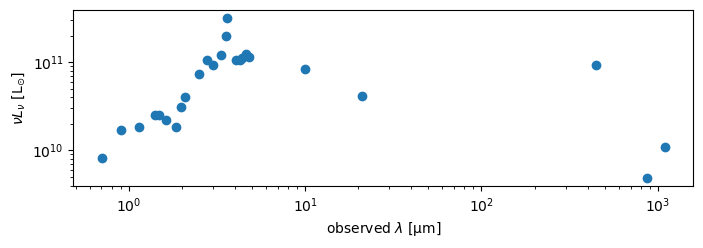

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x='wavelength_obs', y='nu_L_nu', data=Labbe_photo, )
ax.set_xlabel(fr'observed $\lambda$ [{ax.get_xlabel()}]') 
ax.set_ylabel(fr'$\nu L_\nu$ [{ax.get_ylabel()}]') 
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_aspect(.5)
# ax = plt.gca()

## Model

### B87

In [10]:
model = B87Model(n_0= 1e2 * u.cm**-3, gamma=0, L_UV=1e46 * u.erg / u.s, T_sub= 1500 * u.K, NH_target= 7.5e22 * u.cm**-2, opacity=Orion_opacity,)
model.method_L_nu = 'quad'
model.calc_L_nu()

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [4.61617812e+09, 4.67611166e+09, 4.74637448e+09, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00] erg / (Hz s)>

In [11]:
model.IR_Flux(1000 * u.K) 

<Quantity 3.42219478e-16 erg / s>

### SemiOrion

In [48]:
model = SemiOrionLRDModel(n_0=1e3 * u.cm**-3, gamma=.5, L_UV=1e46 * u.erg/u.s, T_sub=1500 * u.K, NH_target=7.5e22 * u.cm**-2, opacity=Orion_opacity, )
model.calc_L_nu()

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


<Quantity [8.84205899e+08, 8.95685869e+08, 9.09144359e+08, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00] erg / (Hz s)>

In [52]:
model.IR_Flux(1000 * u.K, method='trapz', )

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity 3.86279682e-16 erg / s>

### Orion

In [47]:
model = OrionLRDModel(n_0=1e3 * u.cm**-3, gamma=.5, T_sub=1500 * u.K, NH_target=7.5e22 * u.cm**-2, opacity=Orion_opacity, incident_SED=Temple_SED)
model.calc_L_nu()

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


<Quantity [2.01420195e+09, 2.04035306e+09, 2.07101120e+09, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00] erg / (Hz s)>

In [86]:
model.tau_ph =0
(model.calc_L_nu() * model.opacity.nu).max()

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


<Quantity 1.91575331e+45 erg / s>

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


(np.float64(1e+40), np.float64(1e+48))

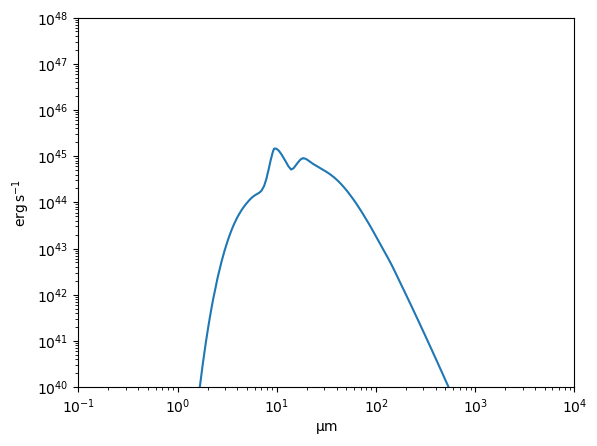

In [105]:
model.tau_ph =1
plt.loglog(model.opacity.wavelength, model.calc_L_nu() * model.opacity.nu)

plt.xlim(1e-1*u.micron, 1e4 * u.micron)
plt.ylim(*[1e40,1e48]*u.erg/u.s)

## 临时测试

In [8]:
from scipy import integrate

In [16]:
integrate.quad(lambda x: x**2, 0 * u.m, 1 * u.m)

TypeError: only dimensionless scalar quantities can be converted to Python scalars

In [35]:
integrate.trapezoid([1,2,4][::1] * u.m, [1, 2, 4][::] * u.m/u.s)

<Quantity 7.5 m2 / s>